STEP 1: Load & Clean the Article Text

In [1]:
!pip install requests beautifulsoup4 nltk

In [2]:
import requests
from bs4 import BeautifulSoup
import re
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
url = "https://www.frontiersin.org/journals/sustainable-cities/articles/10.3389/frsc.2023.1308684/full"

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

In [5]:
# Get all paragraph text
paragraphs = soup.find_all('p')
text = " ".join([p.get_text() for p in paragraphs])

print(text[:1000])  # preview first 1000 characters

Front. Sustain. Cities, 11 January 2024  Sec. Climate Change and Cities Volume 5 - 2023 | https://doi.org/10.3389/frsc.2023.1308684 Frontiers in Sustainable Cities  Part of a Research Topic Towards 2030: A Sustainable Cities Perspective on Achieving Sustainable Development Goal 13 – Climate Action Edited by Ravindra Khaiwal Post Graduate Institute of Medical Education and Research (PGIMER), India Reviewed by Teerachai Amnuaylojaroen University of Phayao, Thailand Akash Biswal Research Institute for Humanity and Nature, Japan Outline  Abstract 1 Introduction 2 Status of climate change in India 3 Climate change impacts 4 Climate change related extreme events in India 5 India's urban transformation and climate change 6 Vulnerable communities 7 Global climate change—Methodologies 8 Climate change mitigations status and strategies for India 9 Conclusion 10 Future directions for climate change studies in India Author contributions Funding Conflict of interest Publisher’s note References Figu

In [6]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# lowercase
text = text.lower()

# remove numbers & punctuation
text = re.sub(r'[^a-z\s]', '', text)

# tokenize
tokens = word_tokenize(text)

# remove stopwords
stop_words = set(stopwords.words('english'))
tokens = [word for word in tokens if word not in stop_words and len(word) > 3]

print(tokens[:50])

['front', 'sustain', 'cities', 'january', 'climate', 'change', 'cities', 'volume', 'httpsdoiorgfrsc', 'frontiers', 'sustainable', 'cities', 'part', 'research', 'topic', 'towards', 'sustainable', 'cities', 'perspective', 'achieving', 'sustainable', 'development', 'goal', 'climate', 'action', 'edited', 'ravindra', 'khaiwal', 'post', 'graduate', 'institute', 'medical', 'education', 'research', 'pgimer', 'india', 'reviewed', 'teerachai', 'amnuaylojaroen', 'university', 'phayao', 'thailand', 'akash', 'biswal', 'research', 'institute', 'humanity', 'nature', 'japan', 'outline']


In [7]:
clean_text = " ".join(tokens)

STEP 2: Topic Modeling

In [8]:
!pip install gensim

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim import corpora
from gensim.models import LdaModel, LsiModel

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
stop_words = set(stopwords.words('english'))

documents = []

for p in paragraphs:
    text = p.get_text().lower()

    # clean text
    text = re.sub(r'[^a-z\s]', '', text)

    # tokenize
    words = word_tokenize(text)

    # remove stopwords + short words
    words = [w for w in words if w not in stop_words and len(w) > 3]

    # keep meaningful paragraphs only
    if len(words) > 10:
        documents.append(words)

print("Number of documents:", len(documents))

Number of documents: 240


In [11]:
dictionary = corpora.Dictionary(documents)

# remove very rare and very common words
dictionary.filter_extremes(no_below=2, no_above=0.5)

corpus = [dictionary.doc2bow(doc) for doc in documents]

print("Vocabulary size:", len(dictionary))

Vocabulary size: 1164


In [12]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=20,
    alpha='auto',
    random_state=42
)

In [13]:
print("===== LDA Topics =====\n")

for i, topic in lda_model.show_topics(num_topics=5, formatted=False):
    words = [word for word, prob in topic]
    print(f"Topic {i}: {words}\n")

===== LDA Topics =====

Topic 0: ['change', 'india', 'pollution', 'precipitation', 'global', 'cities', 'environ', 'impact', 'health', 'sonwani']

Topic 1: ['cities', 'green', 'change', 'health', 'vulnerability', 'infrastructure', 'pollution', 'challenges', 'city', 'original']

Topic 2: ['india', 'change', 'urban', 'heat', 'changes', 'vegetation', 'impacts', 'land', 'pollution', 'temperatures']

Topic 3: ['urban', 'india', 'change', 'green', 'impact', 'cities', 'like', 'temperatures', 'areas', 'temperature']

Topic 4: ['change', 'india', 'impacts', 'forest', 'sustainable', 'global', 'water', 'effects', 'strategies', 'emissions']



In [14]:
lsi_model = LsiModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5
)

In [15]:
print("===== LSI Topics =====\n")

for i, topic in lsi_model.show_topics(num_topics=5, formatted=False):
    words = [word for word, weight in topic]
    print(f"Topic {i}: {words}\n")

===== LSI Topics =====

Topic 0: ['change', 'india', 'urban', 'pollution', 'impacts', 'cities', 'temperatures', 'water', 'impact', 'temperature']

Topic 1: ['urban', 'india', 'green', 'pradesh', 'emissions', 'cities', 'forest', 'temperature', 'infrastructure', 'annual']

Topic 2: ['change', 'urban', 'india', 'pradesh', 'temperature', 'areas', 'vulnerability', 'temperatures', 'green', 'minimum']

Topic 3: ['vulnerability', 'india', 'cities', 'change', 'vegetation', 'temperatures', 'sustainable', 'changes', 'strategies', 'year']

Topic 4: ['vulnerability', 'vegetation', 'pollution', 'forest', 'emissions', 'land', 'floods', 'pradesh', 'plants', 'risk']



STEP 3: Hierarchical Clustering (Dendrogram)

In [16]:
!pip install scipy matplotlib

In [17]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [18]:
topic_vectors = []

for i in range(5):
    topic = lda_model.get_topic_terms(i, topn=10)

    vector = np.zeros(len(dictionary))

    for word_id, prob in topic:
        vector[word_id] = prob

    topic_vectors.append(vector)

topic_vectors = np.array(topic_vectors)

In [19]:
Z = linkage(topic_vectors, method='ward')

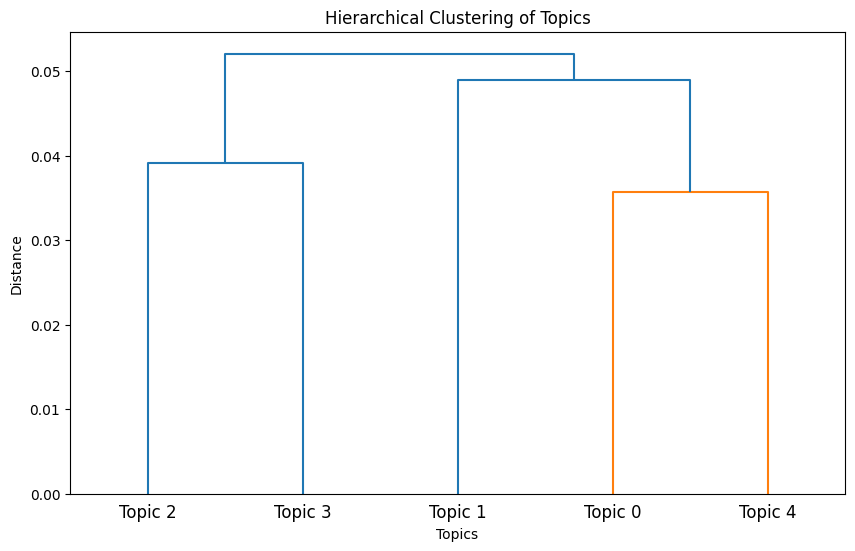

In [20]:
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=[f"Topic {i}" for i in range(5)])
plt.title("Hierarchical Clustering of Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.show()

STEP 4: LLM + Transformers + Top Keywords

In [21]:
!pip install -U transformers sentence-transformers --quiet

In [23]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

prompt = "Summarize the following text:\n" + clean_text[:1000]

output = generator(
    prompt,
    max_length=200,
    num_return_sequences=1
)

print(output[0]['generated_text'])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summarize the following text:
front sustain cities january climate change cities volume httpsdoiorgfrsc frontiers sustainable cities part research topic towards sustainable cities perspective achieving sustainable development goal climate action edited ravindra khaiwal post graduate institute medical education research pgimer india reviewed teerachai amnuaylojaroen university phayao thailand akash biswal research institute humanity nature japan outline abstract introduction status climate change india climate change impacts climate change related extreme events india indias urban transformation climate change vulnerable communities global climate changemethodologies climate change mitigations status strategies india conclusion future directions climate change studies india author contributions funding conflict interest publishers note references figure figure figure figure figure figure table table listing projected changes different climate variables india adapted krishnan front susta